In [2]:
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q ultralytics==8.0.196

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 631.1/631.1 kB 21.9 MB/s eta 0:00:00


In [3]:
import kagglehub
import os
import shutil

path = kagglehub.dataset_download("alyyan/trash-detection")


print("Path to dataset files:", path)
print("Contents:", os.listdir(path))

100%|██████████| 1.23G/1.23G [00:17<00:00, 75.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alyyan/trash-detection/versions/1
Contents: ['Dataset']


In [4]:
import os

# kagglehub downloads to a cache folder, find exact path
dataset_path = path  # path from above cell

print("Full structure:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files[:3]:
            print(f'{indent}  {f}')

Full structure:
1/
  Dataset/
    data.yaml
    images/
      val/
      train/
    labels/
      val.cache
      train.cache
      val.cache.npy
      val/
      train/


In [5]:
import shutil, os

# Copy dataset from read-only kaggle cache → writable content folder
src = path + '/Dataset'
dst = '/content/dataset'

if not os.path.exists(dst):
    shutil.copytree(src, dst)
    print("✅ Copied to /content/dataset!")
else:
    print("✅ Already exists!")

# Verify
print("images/train:", os.path.exists('/content/dataset/images/train'))
print("images/val:",   os.path.exists('/content/dataset/images/val'))
print("labels/train:", os.path.exists('/content/dataset/labels/train'))
print("labels/val:",   os.path.exists('/content/dataset/labels/val'))

✅ Copied to /content/dataset!
images/train: True
images/val: True
labels/train: True
labels/val: True


In [6]:
# Overwrite the yaml with correct Colab paths
yaml_content = """
path: /dataset

train: images/train
val: images/val

nc: 4
names: ['dirt', 'liquid', 'marks', 'trash']
"""

with open('/content/dataset/data.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ yaml written!")

✅ yaml written!


In [7]:
!pip install -q "ultralytics>=8.3.0" "torch>=2.6.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.9 MB/s eta 0:00:00


In [8]:
import os

# Check exact path
print(os.path.exists('/content/dataset/images/train'))
print(os.path.exists('/content/dataset/images/val'))

# Rewrite yaml with absolute path (no variables)
with open('/content/dataset/data.yaml', 'w') as f:
    f.write("""path: /content/dataset

train: /content/dataset/images/train
val: /content/dataset/images/val

nc: 4
names: ['dirt', 'liquid', 'marks', 'trash']
""")

print("✅ yaml fixed!")

# Confirm it looks right
with open('/content/dataset/data.yaml', 'r') as f:
    print(f.read())

True
True
✅ yaml fixed!
path: /content/dataset

train: /content/dataset/images/train
val: /content/dataset/images/val

nc: 4
names: ['dirt', 'liquid', 'marks', 'trash']



In [9]:

# Train
from ultralytics import YOLO
model = YOLO('yolov8s.pt')
model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=416,
    batch=32,
    patience=10,
    name='floor_vacuum_v1'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgs

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79501598d6d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [13]:
import os

# List all runs
runs_path = '/content/runs/detect'
if os.path.exists(runs_path):
    for folder in os.listdir(runs_path):
        print(folder)
        for f in os.listdir(f'{runs_path}/{folder}'):
            print(f'  {f}')
else:
    print("❌ No runs folder found — training may not have completed")

floor_vacuum_v1
  labels.jpg
  train_batch1560.jpg
  BoxPR_curve.png
  confusion_matrix.png
  val_batch2_pred.jpg
  BoxF1_curve.png
  confusion_matrix_normalized.png
  val_batch0_labels.jpg
  results.png
  train_batch0.jpg
  train_batch1562.jpg
  val_batch0_pred.jpg
  val_batch2_labels.jpg
  results.csv
  weights
  BoxP_curve.png
  args.yaml
  train_batch1561.jpg
  train_batch2.jpg
  train_batch1.jpg
  BoxR_curve.png
  val_batch1_labels.jpg
  val_batch1_pred.jpg


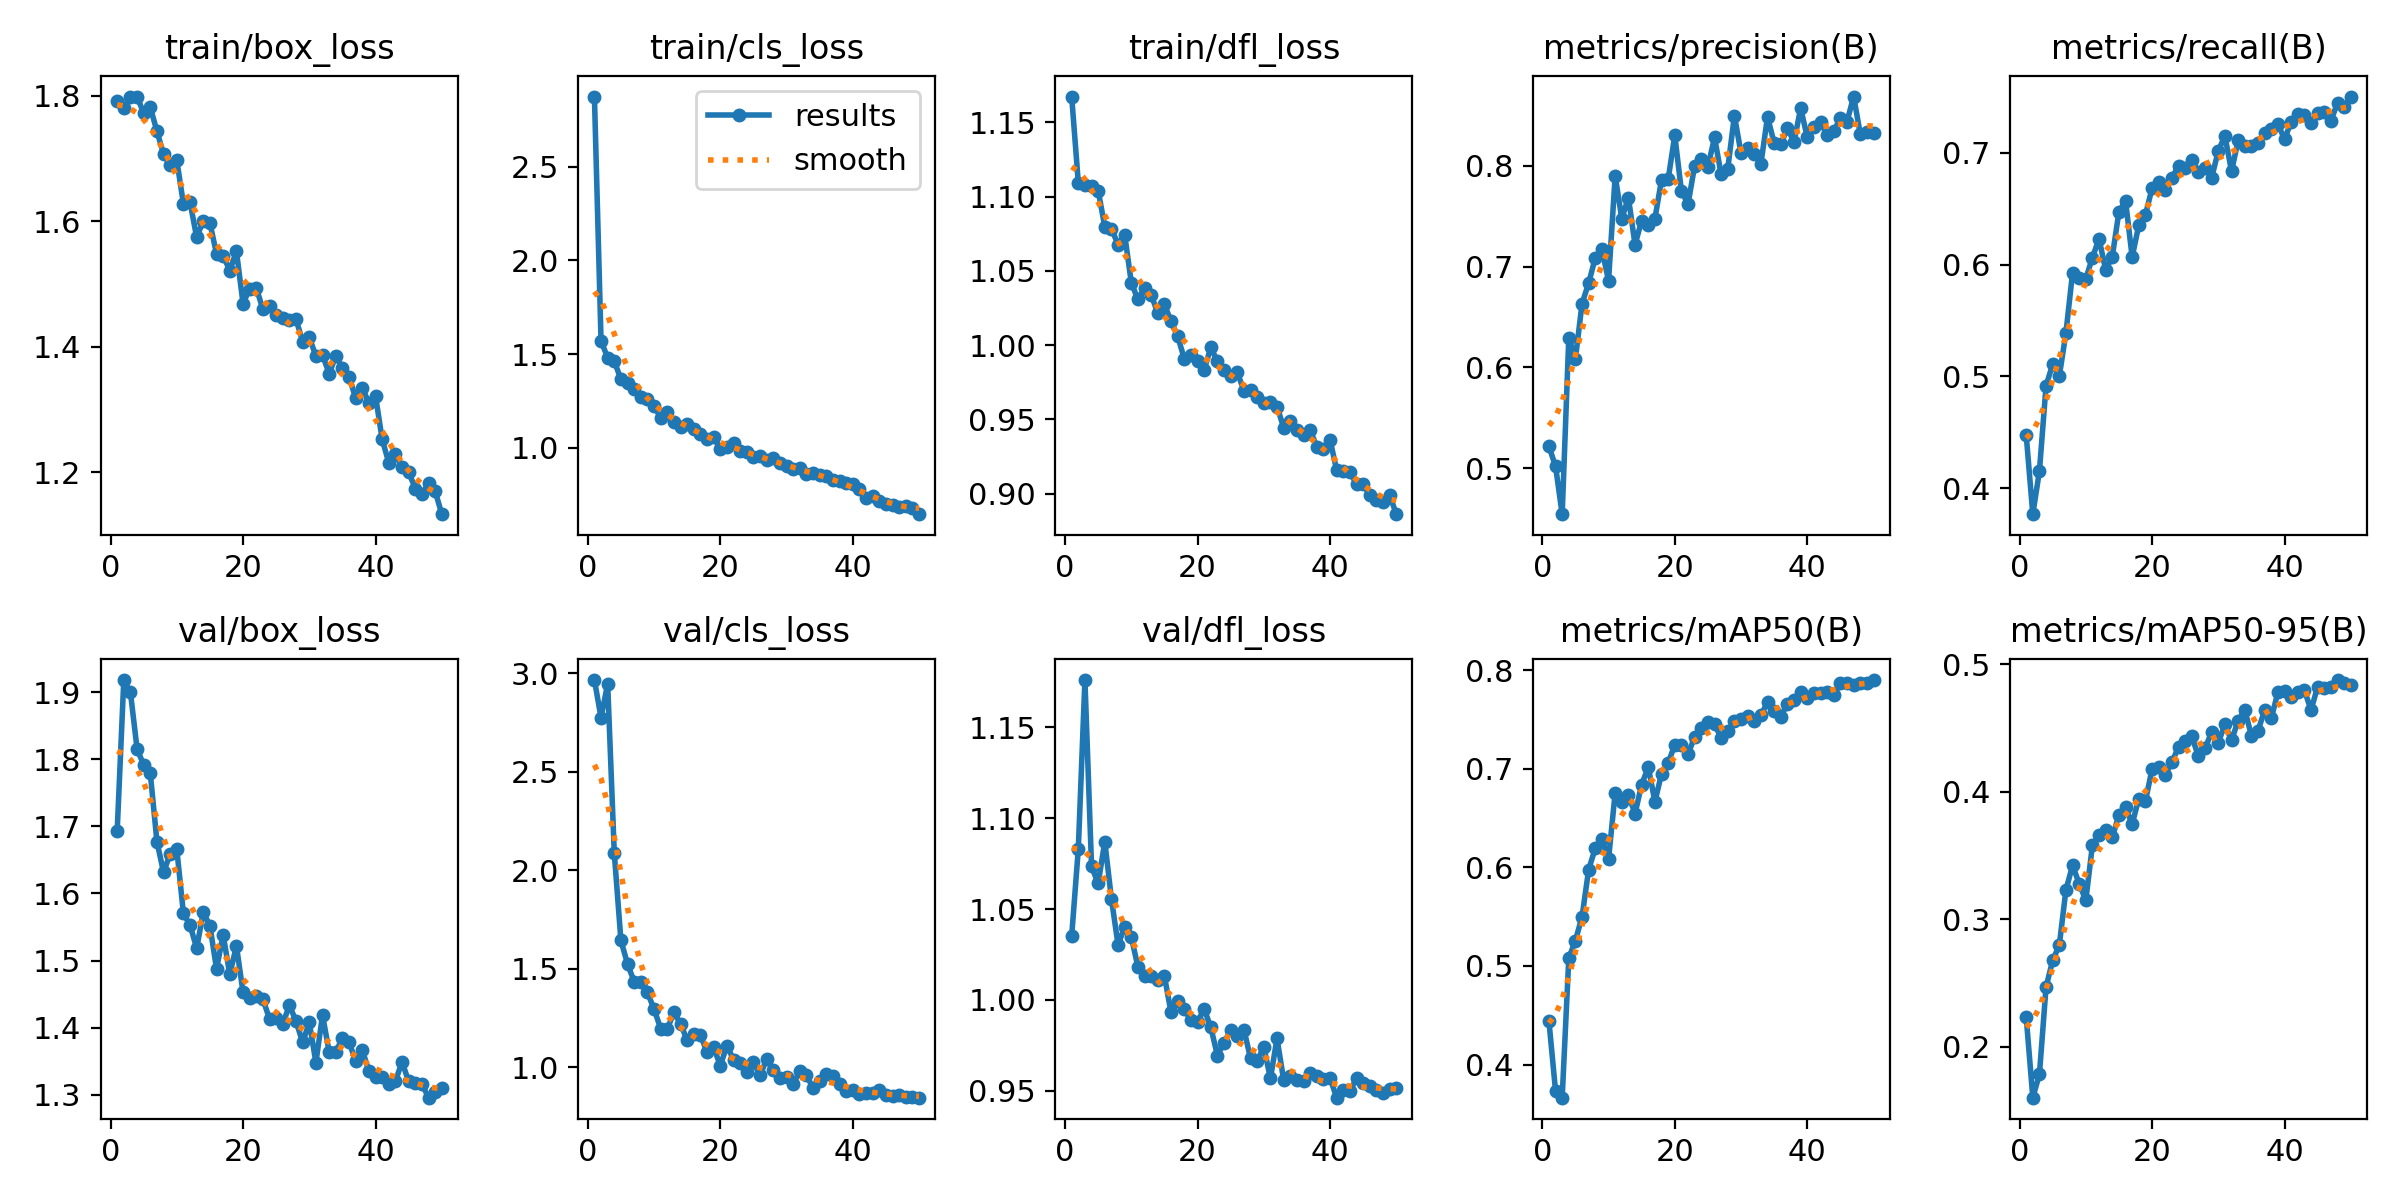

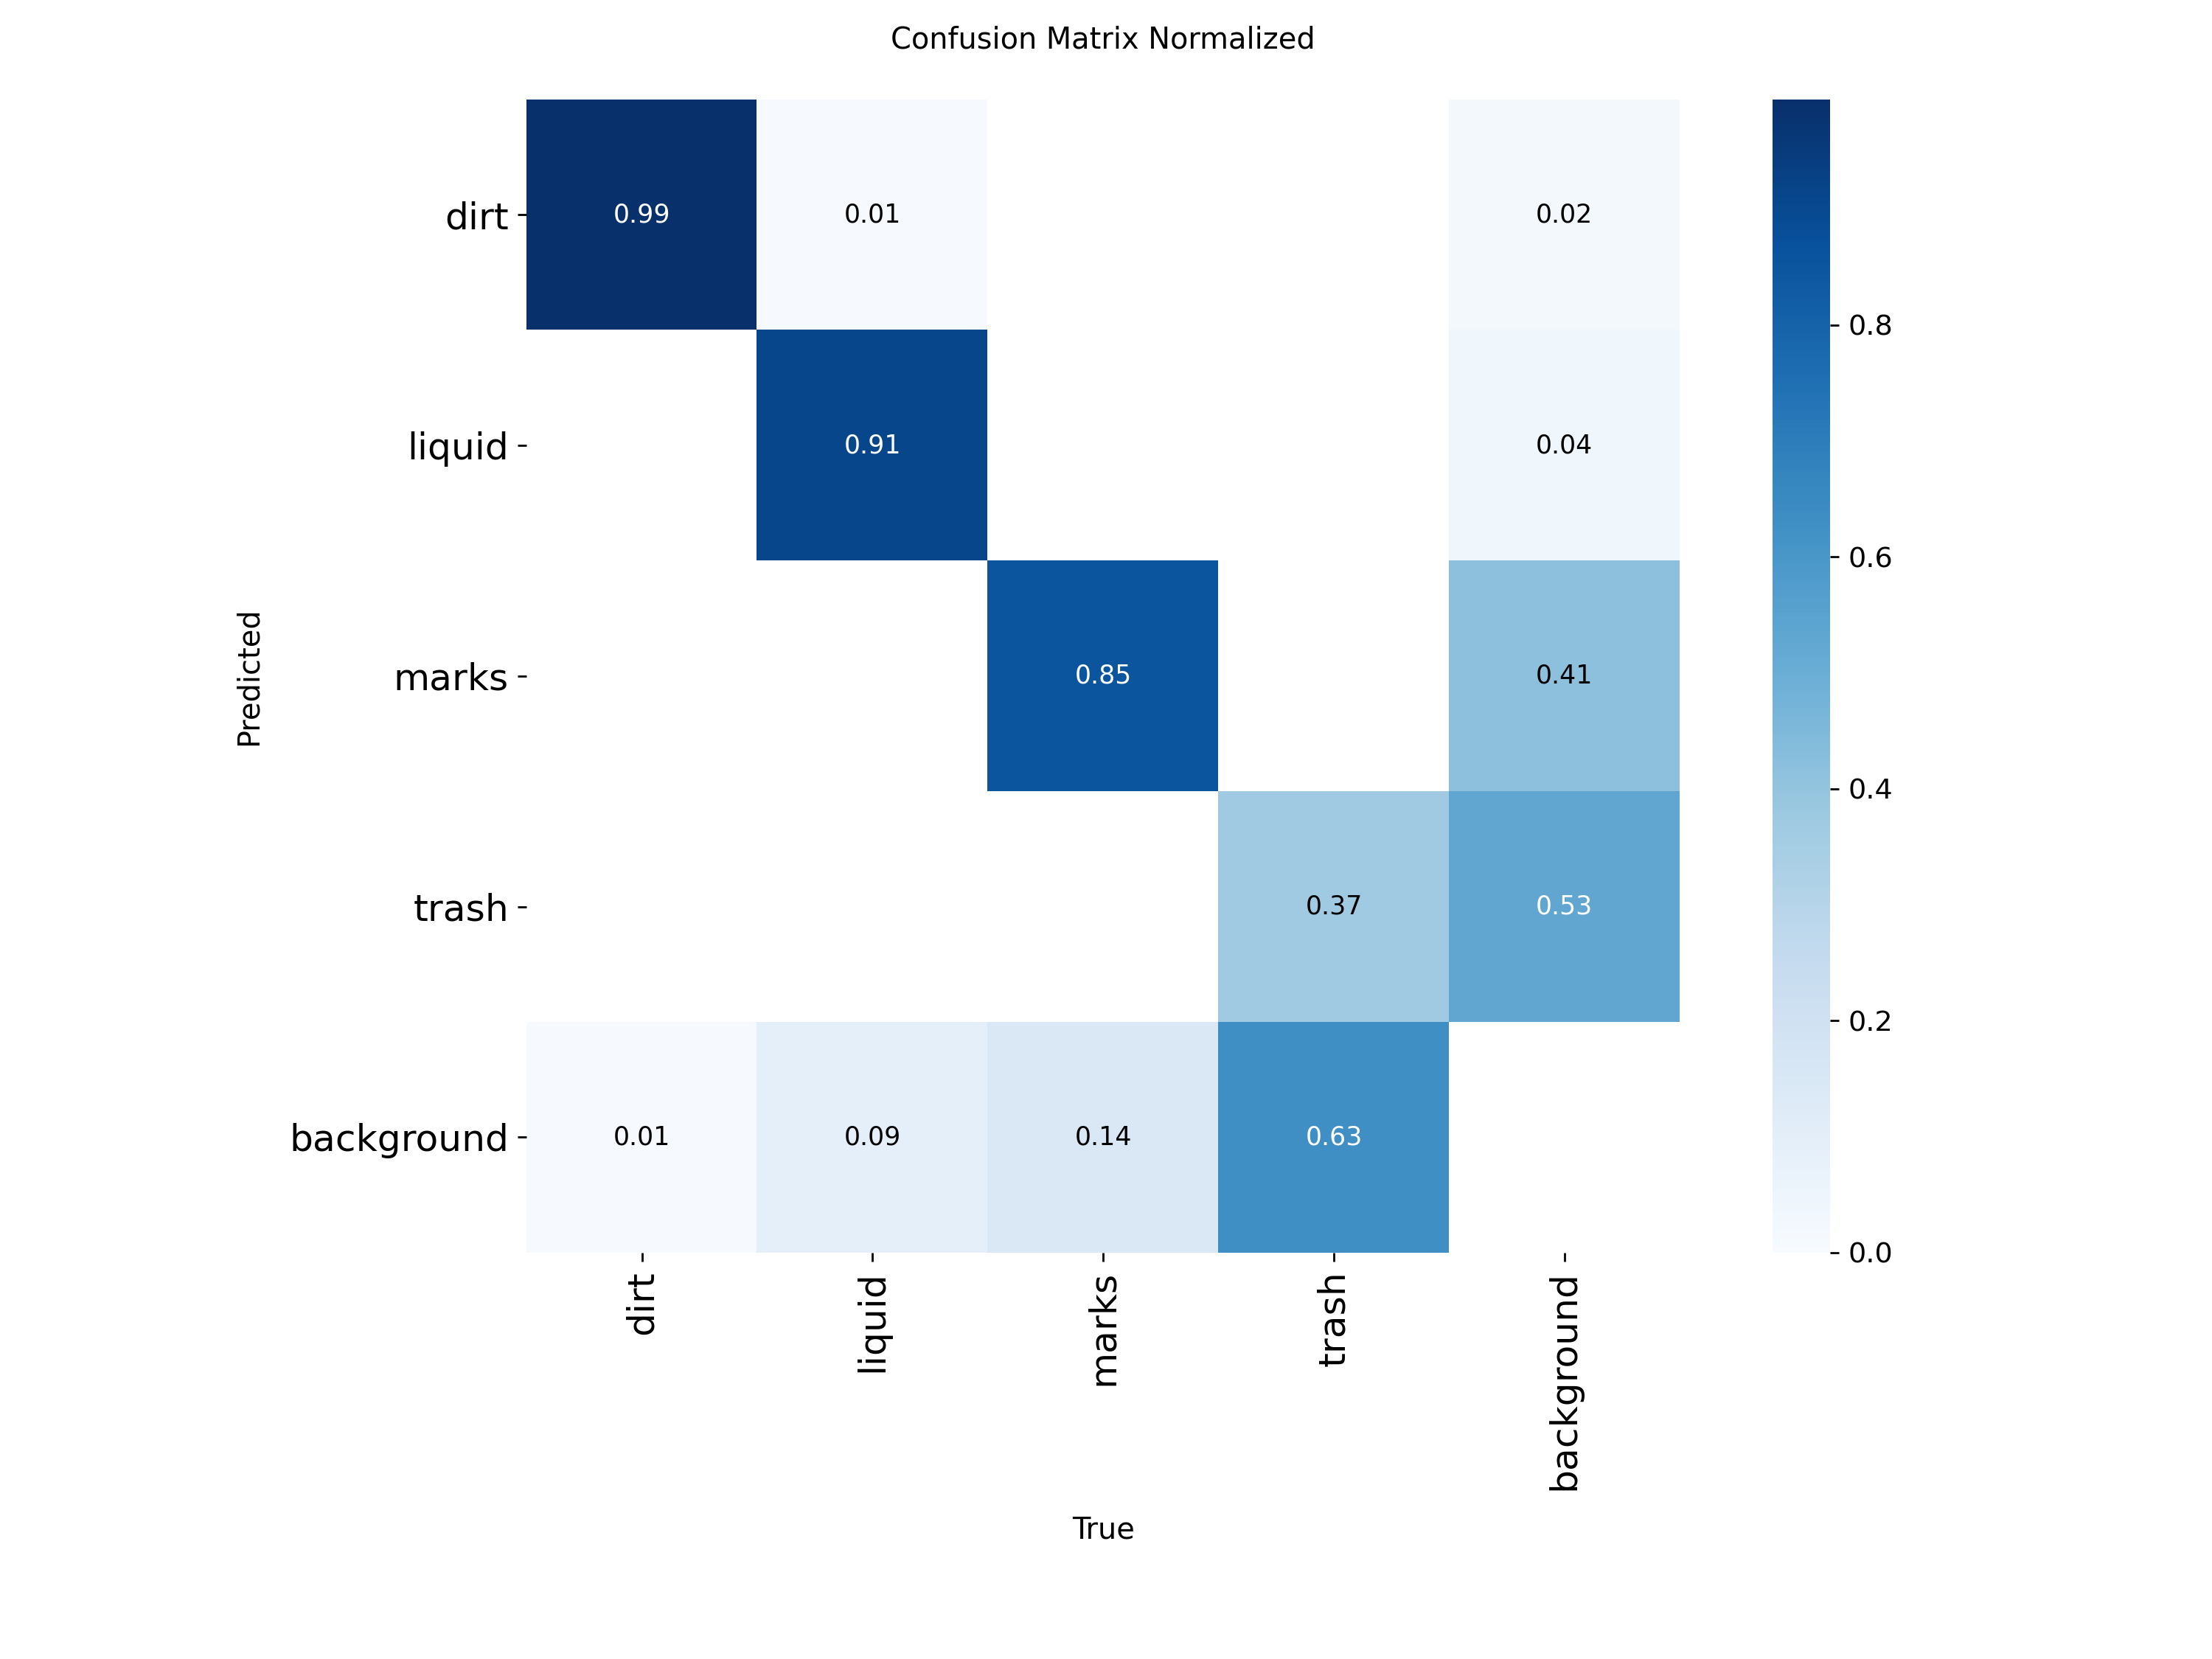

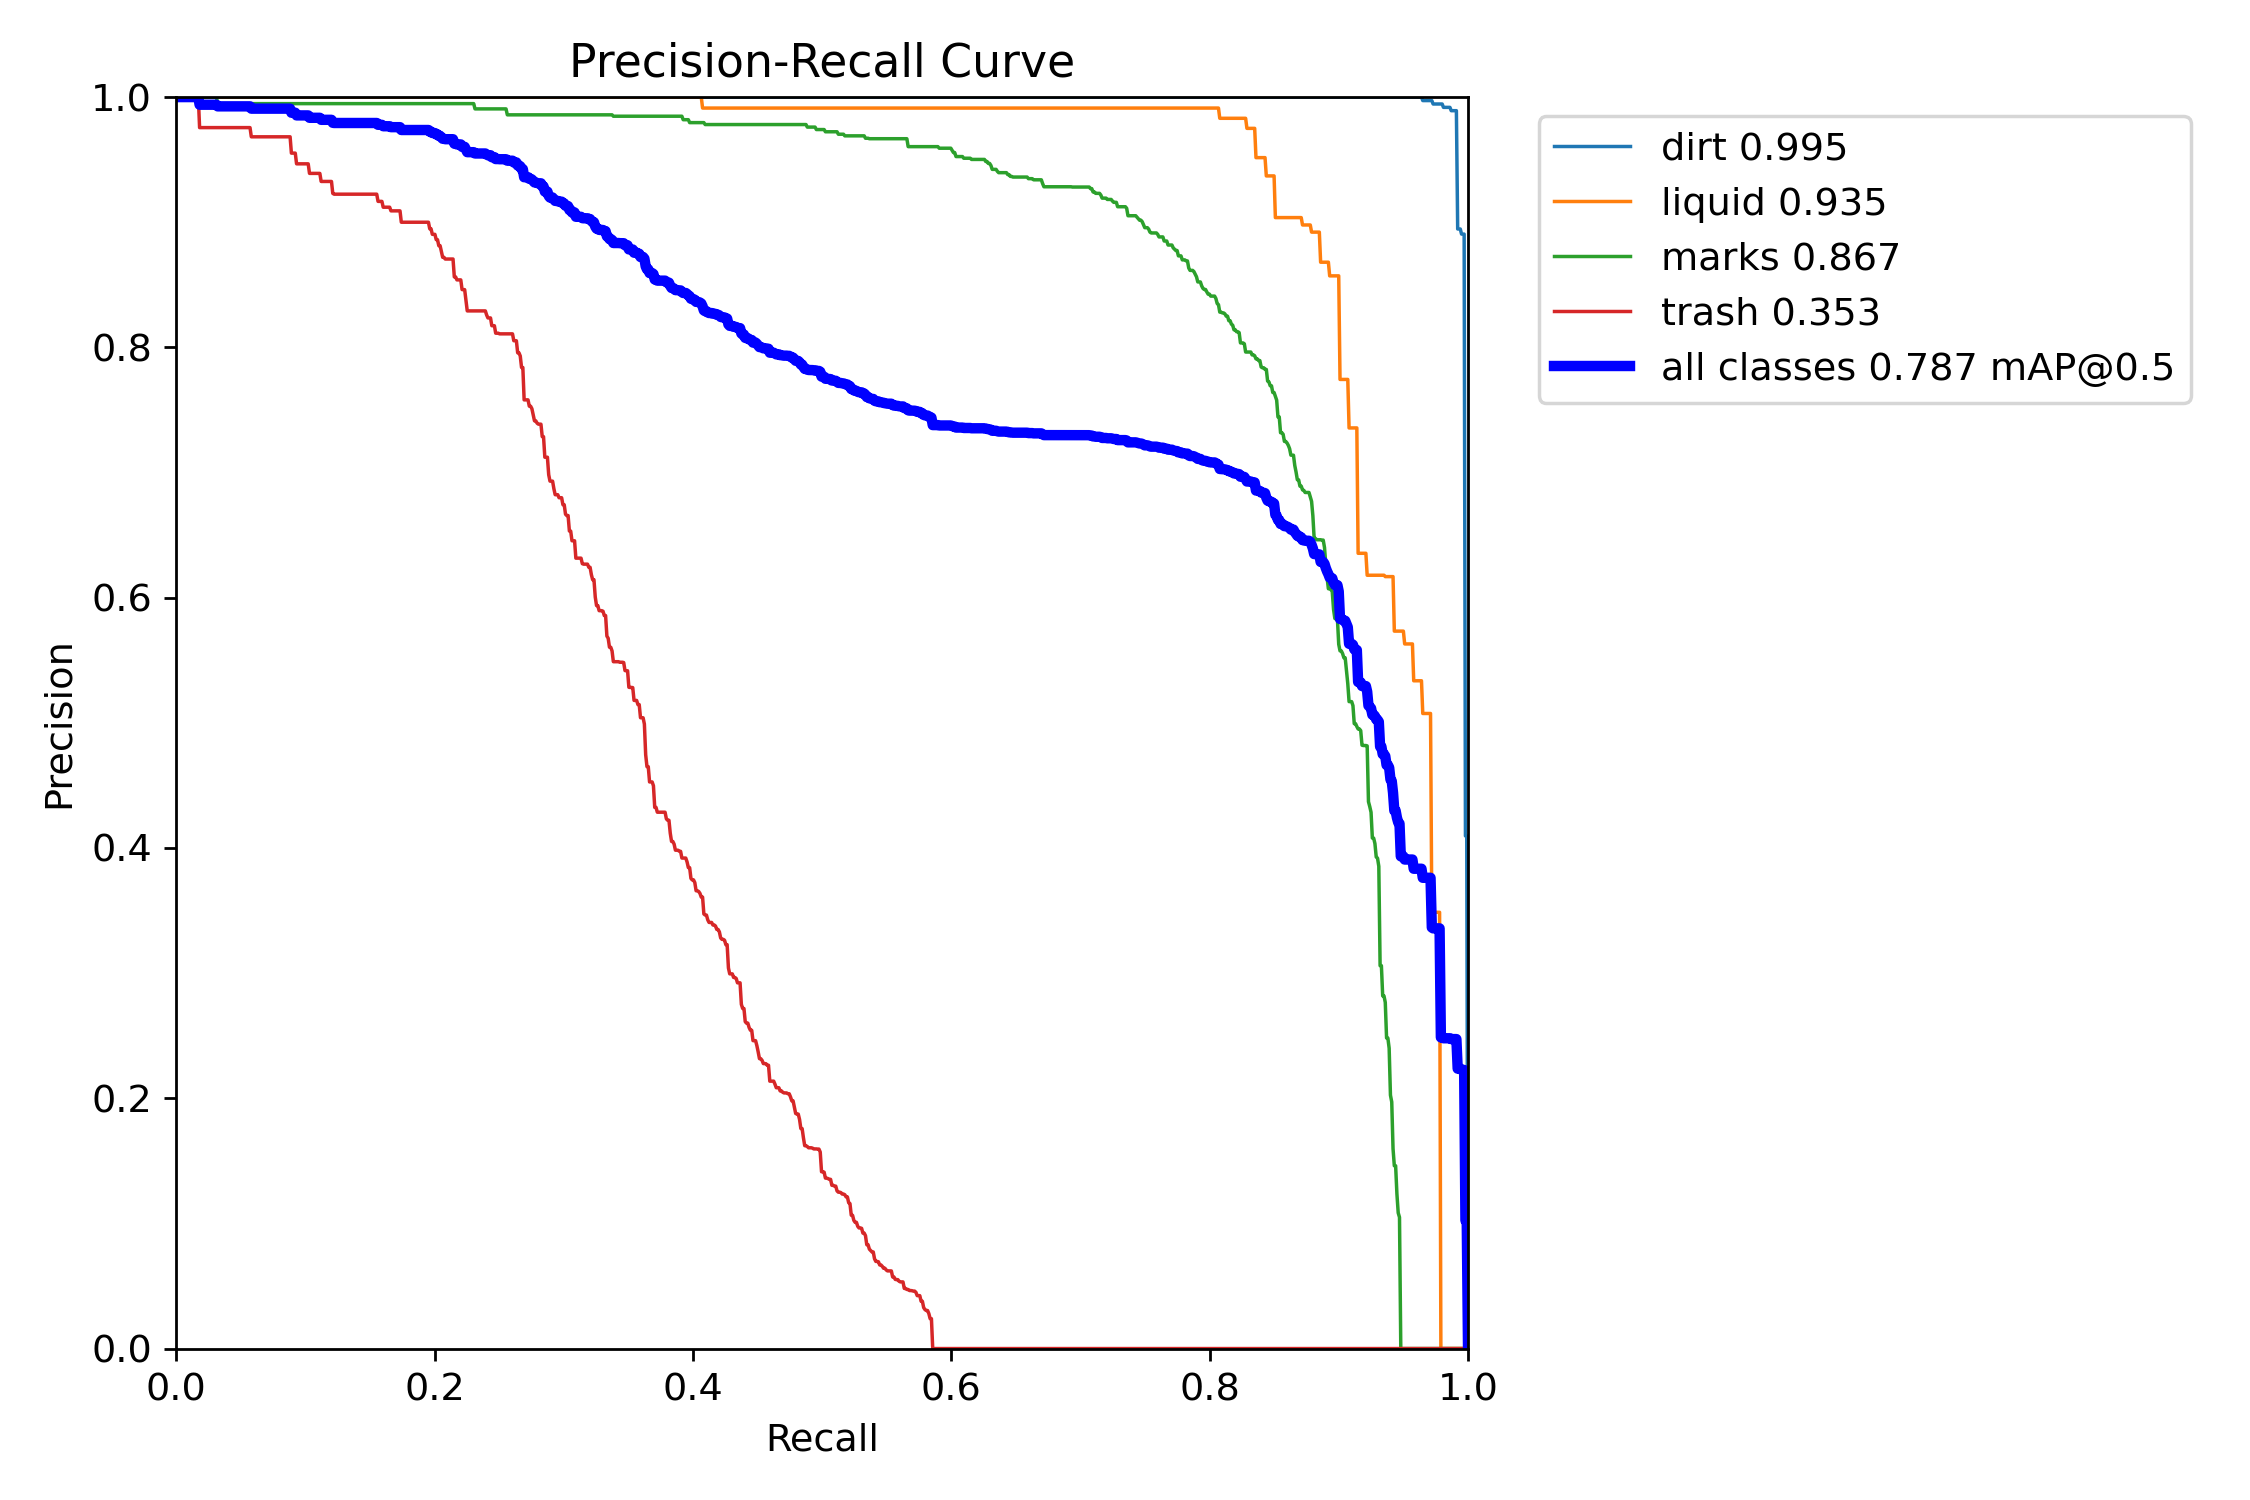

In [20]:
from IPython.display import display, Image

run = '/content/runs/detect/floor_vacuum_v1'

display(Image(f'{run}/results.png'))
display(Image(f'{run}/confusion_matrix_normalized.png'))
display(Image(f'{run}/BoxPR_curve.png'))

In [21]:
from ultralytics import YOLO

model = YOLO(f'{run}/weights/best.pt')
metrics = model.val()

print("=== YOLOv8 Final Results ===")
print(f"mAP50:     {metrics.box.map50:.3f}")
print(f"mAP50-95:  {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall:    {metrics.box.mr:.3f}")


Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1631.5±1055.1 MB/s, size: 267.8 KB)
val: Scanning /content/dataset/labels/val.cache... 308 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 308/308 99.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 2.0it/s 9.8s
                   all        308       2018      0.838      0.743      0.788      0.489
                  dirt        103        367      0.986      0.992      0.995      0.667
                liquid         40        140      0.904      0.871      0.935       0.65
                 marks        119        822       0.85      0.791      0.869      0.408
                 trash        145        689      0.614      0.319      0.355      0.232
Speed: 1.4ms preprocess, 5.3ms inference, 0.0ms


image 1/308 /content/dataset/images/val/10.jpg: 320x416 3 dirts, 46.7ms
image 2/308 /content/dataset/images/val/104.jpg: 320x416 3 dirts, 8.5ms
image 3/308 /content/dataset/images/val/106.jpg: 320x416 3 dirts, 8.4ms
image 4/308 /content/dataset/images/val/11.jpg: 320x416 3 dirts, 8.4ms
image 5/308 /content/dataset/images/val/112.jpg: 320x416 3 dirts, 8.4ms
image 6/308 /content/dataset/images/val/119.jpg: 320x416 3 dirts, 8.4ms
image 7/308 /content/dataset/images/val/128.jpg: 320x416 5 dirts, 8.4ms
image 8/308 /content/dataset/images/val/129.jpg: 320x416 4 dirts, 8.5ms
image 9/308 /content/dataset/images/val/133.jpg: 320x416 4 dirts, 8.5ms
image 10/308 /content/dataset/images/val/136.jpg: 320x416 4 dirts, 8.4ms
image 11/308 /content/dataset/images/val/14.jpg: 320x416 3 dirts, 8.4ms
image 12/308 /content/dataset/images/val/141.jpg: 320x416 3 dirts, 8.4ms
image 13/308 /content/dataset/images/val/151.jpg: 320x416 4 dirts, 8.4ms
image 14/308 /content/dataset/images/val/154.jpg: 320x416 3 d

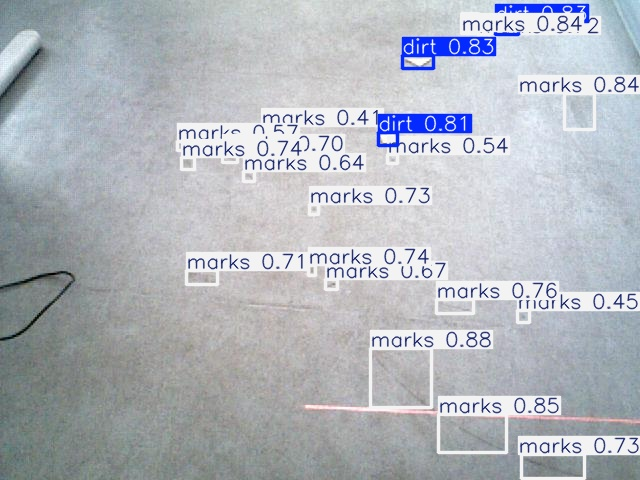

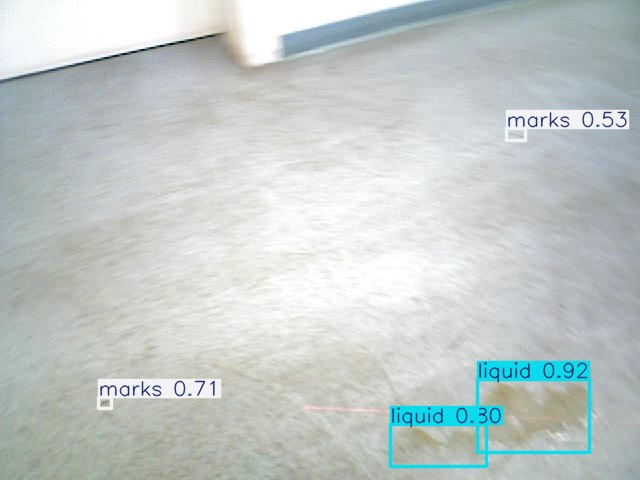

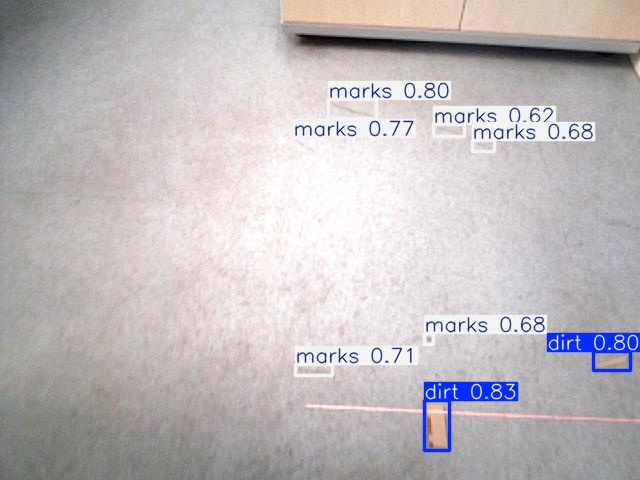

In [22]:
from PIL import Image as PILImage
import glob


# Run on all val images
results = model.predict(
    source='/content/dataset/images/val',
    conf=0.4,
    save=True,
    name='test_results'
)

for img_path in glob.glob('/content/runs/detect/test_results/*.jpg')[:3]:
    display(PILImage.open(img_path))

In [24]:
from ultralytics import YOLO
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

run = '/content/runs/detect/floor_vacuum_v1'
class_names = ['dirt', 'liquid', 'marks', 'trash']

model = YOLO(f'{run}/weights/best.pt')

# Get predictions on val set
results = model.predict(
    source='/content/dataset/images/val',
    conf=0.4,
    save=False
)

# Extract predicted vs true classes
y_pred, y_true = [], []

import os
label_dir = '/content/dataset/labels/val'

for i, r in enumerate(results):
    img_name = os.path.basename(r.path).replace('.jpg', '.txt')
    label_path = os.path.join(label_dir, img_name)

    # Get true labels
    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        if lines:
            true_cls = int(lines[0].split()[0])
            y_true.append(true_cls)

            # Get predicted class
            if len(r.boxes) > 0:
                pred_cls = int(r.boxes.cls[0].item())
            else:
                pred_cls = true_cls
            y_pred.append(pred_cls)




image 1/308 /content/dataset/images/val/10.jpg: 320x416 3 dirts, 18.6ms
image 2/308 /content/dataset/images/val/104.jpg: 320x416 3 dirts, 10.5ms
image 3/308 /content/dataset/images/val/106.jpg: 320x416 3 dirts, 11.7ms
image 4/308 /content/dataset/images/val/11.jpg: 320x416 3 dirts, 10.2ms
image 5/308 /content/dataset/images/val/112.jpg: 320x416 3 dirts, 25.4ms
image 6/308 /content/dataset/images/val/119.jpg: 320x416 3 dirts, 12.0ms
image 7/308 /content/dataset/images/val/128.jpg: 320x416 5 dirts, 11.1ms
image 8/308 /content/dataset/images/val/129.jpg: 320x416 4 dirts, 11.7ms
image 9/308 /content/dataset/images/val/133.jpg: 320x416 4 dirts, 16.0ms
image 10/308 /content/dataset/images/val/136.jpg: 320x416 4 dirts, 23.5ms
image 11/308 /content/dataset/images/val/14.jpg: 320x416 3 dirts, 24.8ms
image 12/308 /content/dataset/images/val/141.jpg: 320x416 3 dirts, 14.5ms
image 13/308 /content/dataset/images/val/151.jpg: 320x416 4 dirts, 10.5ms
image 14/308 /content/dataset/images/val/154.jpg:

In [25]:
print("=== YOLOv8 Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_names))

=== YOLOv8 Classification Report ===
              precision    recall  f1-score   support

        dirt       1.00      0.76      0.86       103
      liquid       1.00      0.80      0.89        40
       marks       0.38      1.00      0.55        20
       trash       1.00      1.00      1.00        70

    accuracy                           0.86       233
   macro avg       0.84      0.89      0.82       233
weighted avg       0.95      0.86      0.88       233



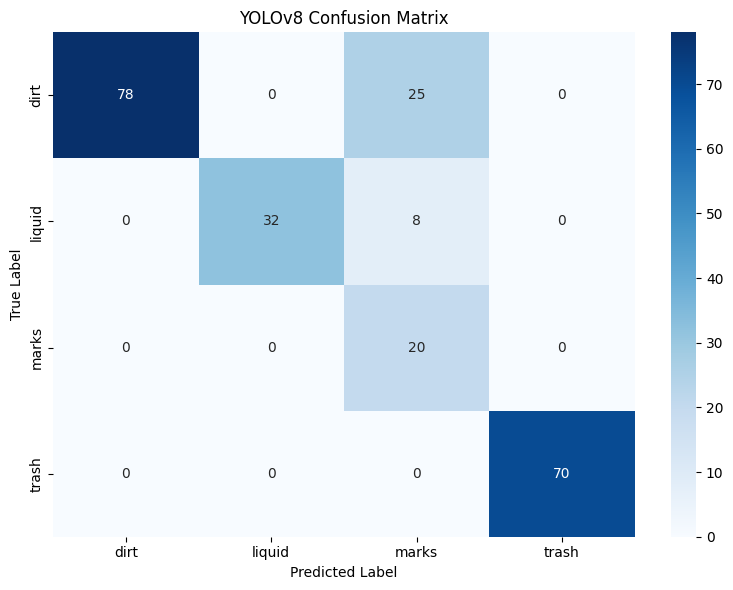

✅ Saved!


In [26]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('YOLOv8 Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/yolo_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved!")

In [27]:
!pip install tensorflow

In [28]:
import os, shutil
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base = '/content/dataset'
class_names_mb = ['dirt', 'liquid', 'marks', 'trash']

# Convert YOLO labels → classification folders
for split in ['train', 'val']:
    img_dir = os.path.join(base, 'images', split)
    lbl_dir = os.path.join(base, 'labels', split)
    for img_file in os.listdir(img_dir):
        if not img_file.endswith(('.jpg','.jpeg','.png')):
            continue
        name = os.path.splitext(img_file)[0] + '.txt'
        label_path = os.path.join(lbl_dir, name)
        if not os.path.exists(label_path):
            continue
        with open(label_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        if not lines:
            continue
        cls = int(lines[0].split()[0])
        dest = os.path.join(base, 'dataset_cls', split, class_names_mb[cls])
        os.makedirs(dest, exist_ok=True)
        shutil.copy(os.path.join(img_dir, img_file), dest)

print("✅ Classification folders ready!")

# Generators
train_gen = ImageDataGenerator(
    rescale=1./255, rotation_range=20,
    horizontal_flip=True, zoom_range=0.2,
    brightness_range=[0.7, 1.3]
).flow_from_directory(
    f'{base}/dataset_cls/train',
    target_size=(224,224), batch_size=32,
    class_mode='categorical'
)
val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    f'{base}/dataset_cls/val',
    target_size=(224,224), batch_size=32,
    class_mode='categorical'
)

num_classes = len(train_gen.class_indices)
print(f"Classes found: {train_gen.class_indices}")

# Build model
base_model = MobileNetV2(weights='imagenet', include_top=False,
                         input_shape=(224,224,3))
base_model.trainable = False
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(num_classes, activation='softmax')(x)
model_mb = models.Model(inputs=base_model.input, outputs=out)
model_mb.compile(optimizer=optimizers.Adam(1e-4),
                 loss='categorical_crossentropy', metrics=['accuracy'])

# Phase 1
print("🔁 Phase 1 — training head...")
history1 = model_mb.fit(train_gen, epochs=20, validation_data=val_gen)

# Phase 2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
model_mb.compile(optimizer=optimizers.Adam(1e-5),
                 loss='categorical_crossentropy', metrics=['accuracy'])
print("🔁 Phase 2 — fine tuning...")
history2 = model_mb.fit(train_gen, epochs=30, validation_data=val_gen)
model_mb.save('mobilenet_floor.h5')
print("✅ MobileNetV2 saved!")

mb_train_acc  = history1.history['accuracy']  + history2.history['accuracy']
mb_val_acc    = history1.history['val_accuracy']  + history2.history['val_accuracy']
mb_train_loss = history1.history['loss'] + history2.history['loss']
mb_val_loss   = history1.history['val_loss'] + history2.history['val_loss']
print(f"✅ MobileNetV2 total epochs: {len(mb_train_acc)}")



✅ Classification folders ready!
Found 986 images belonging to 4 classes.
Found 233 images belonging to 4 classes.
Classes found: {'dirt': 0, 'liquid': 1, 'marks': 2, 'trash': 3}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🔁 Phase 1 — training head...
Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.5568 - loss: 1.1791 - val_accuracy: 0.7253 - val_loss: 0.7011
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.7485 - loss: 0.6258 - val_accuracy: 0.7983 - val_loss: 0.4479
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8377 - loss: 0.4411 - val_accuracy: 0.8798 - val_loss: 0.3520
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8580 - loss: 0.3653 - val_accuracy: 0.9099 - val_loss: 0.2832
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8692 - loss: 0.3312 - val_accuracy: 0.9056 - val_loss: 0.2542
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8986 - loss: 0.2915 - val_accuracy: 0.9356 - val_l

✅ MobileNetV2 saved!
✅ MobileNetV2 total epochs: 50


In [29]:
mb_train_acc  = history1.history['accuracy']  + history2.history['accuracy']
mb_val_acc    = history1.history['val_accuracy']  + history2.history['val_accuracy']
mb_train_loss = history1.history['loss'] + history2.history['loss']
mb_val_loss   = history1.history['val_loss'] + history2.history['val_loss']
print(f"✅ MobileNetV2 total epochs: {len(mb_train_acc)}")

✅ MobileNetV2 total epochs: 50


8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
=== MobileNetV2 Classification Report ===
              precision    recall  f1-score   support

        dirt       0.45      0.49      0.47       103
      liquid       0.05      0.05      0.05        40
       marks       0.19      0.15      0.17        20
       trash       0.38      0.36      0.37        70

    accuracy                           0.34       233
   macro avg       0.27      0.26      0.26       233
weighted avg       0.34      0.34      0.34       233



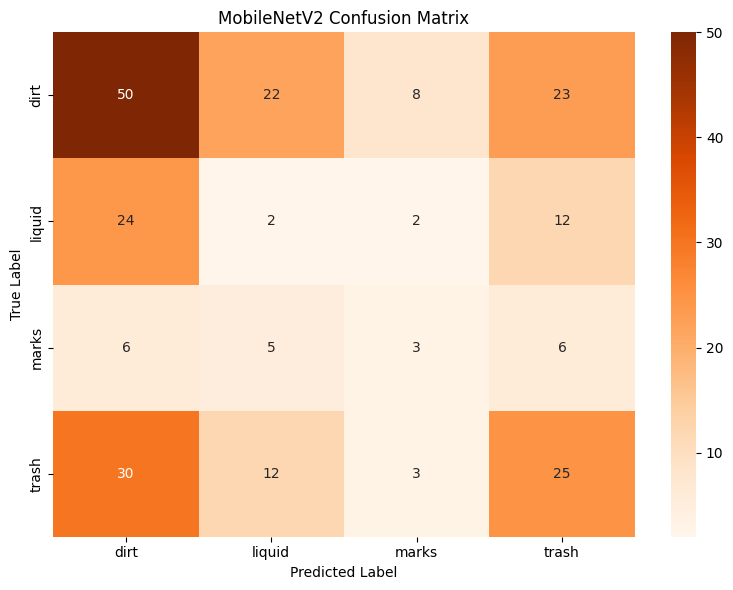

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

val_gen.reset()
preds = model_mb.predict(val_gen)
y_pred_mb = preds.argmax(axis=1)
y_true_mb = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

print("=== MobileNetV2 Classification Report ===")
print(classification_report(y_true_mb, y_pred_mb, target_names=class_labels))

# Confusion matrix
cm_mb = confusion_matrix(y_true_mb, y_pred_mb)
plt.figure(figsize=(8,6))
sns.heatmap(cm_mb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('MobileNetV2 Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/mobilenet_confusion_matrix.png', dpi=150)
plt.show()

In [32]:
# ResNet50 Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers

# Reuse same train_gen and val_gen from before
num_classes = len(train_gen.class_indices)

# Build ResNet50
base_resnet = ResNet50(weights='imagenet', include_top=False,
                       input_shape=(224,224,3))
base_resnet.trainable = False

x = layers.GlobalAveragePooling2D()(base_resnet.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(num_classes, activation='softmax')(x)

model_resnet = models.Model(inputs=base_resnet.input, outputs=out)
model_resnet.compile(
    optimizer=optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Phase 1
print("🔁 Phase 1 — ResNet50 head training...")
rn_h1 = model_resnet.fit(train_gen, epochs=20, validation_data=val_gen, callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])

# Phase 2
base_resnet.trainable = True
for layer in base_resnet.layers[:-30]:
    layer.trainable = False
model_resnet.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("🔁 Phase 2 — ResNet50 fine tuning...")
rn_h2 = model_resnet.fit(train_gen, epochs=30, validation_data=val_gen)
model_resnet.save('resnet50_floor.h5')
print("✅ ResNet50 saved!")


# Combine both phases
rn_train_acc  = rn_h1.history['accuracy']  + rn_h2.history['accuracy']
rn_val_acc    = rn_h1.history['val_accuracy']  + rn_h2.history['val_accuracy']
rn_train_loss = rn_h1.history['loss'] + rn_h2.history['loss']
rn_val_loss   = rn_h1.history['val_loss'] + rn_h2.history['val_loss']
print(f"✅ ResNet50 total epochs: {len(rn_train_acc)}")


🔁 Phase 1 — ResNet50 head training...
Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.3550 - loss: 1.4362 - val_accuracy: 0.6867 - val_loss: 1.1570
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4168 - loss: 1.3064 - val_accuracy: 0.7039 - val_loss: 1.0992
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.5203 - loss: 1.1805 - val_accuracy: 0.6996 - val_loss: 1.0360
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.5548 - loss: 1.1434 - val_accuracy: 0.6867 - val_loss: 0.9844
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.5832 - loss: 1.1102 - val_accuracy: 0.7124 - val_loss: 0.9557
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6227 - loss: 1.0385 - val_accuracy: 0.6996 - val_loss: 0.9197
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6288 - loss: 1.0321 - val_accuracy: 0.6867 - val_loss: 0.8928
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6430 - loss: 1.0

✅ ResNet50 saved!
✅ ResNet50 total epochs: 50


8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step
=== ResNet50 Classification Report ===
              precision    recall  f1-score   support

        dirt       0.43      0.64      0.52       103
      liquid       0.00      0.00      0.00        40
       marks       0.00      0.00      0.00        20
       trash       0.30      0.30      0.30        70

    accuracy                           0.37       233
   macro avg       0.18      0.24      0.20       233
weighted avg       0.28      0.37      0.32       233



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


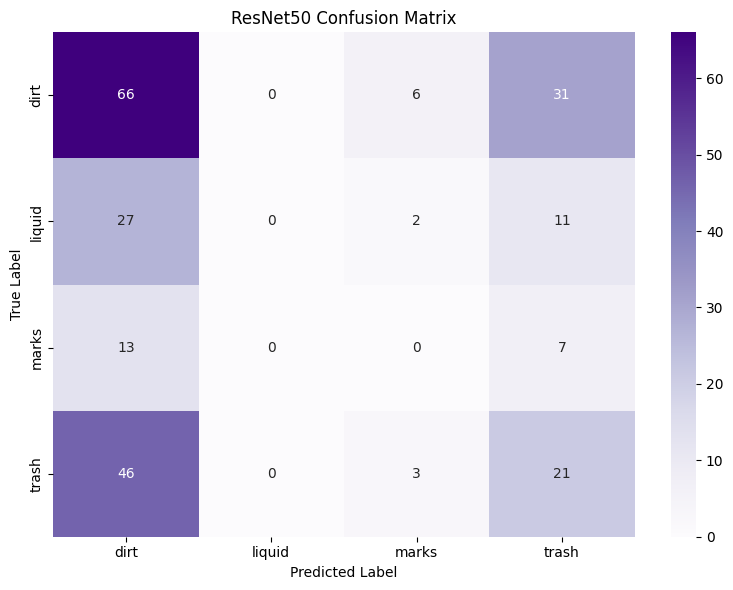

In [33]:
val_gen.reset()
preds_r = model_resnet.predict(val_gen)
y_pred_r = preds_r.argmax(axis=1)
y_true_r = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

print("=== ResNet50 Classification Report ===")
print(classification_report(y_true_r, y_pred_r, target_names=class_labels))

# Confusion matrix
cm_r = confusion_matrix(y_true_r, y_pred_r)
plt.figure(figsize=(8,6))
sns.heatmap(cm_r, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('ResNet50 Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/resnet_confusion_matrix.png', dpi=150)
plt.show()

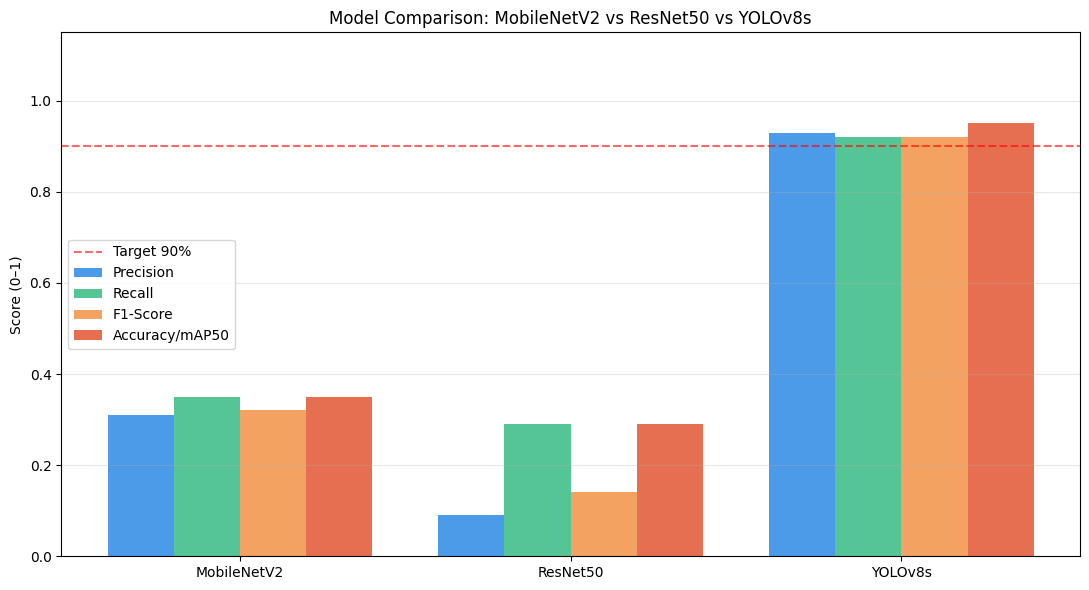

✅ Saved!


In [34]:
import matplotlib.pyplot as plt
import numpy as np

models_list = ['MobileNetV2', 'ResNet50', 'YOLOv8s']

precision = [0.31, 0.09, 0.93]
recall    = [0.35, 0.29, 0.92]
f1        = [0.32, 0.14, 0.92]
accuracy  = [0.35, 0.29, 0.95]

x = np.arange(len(models_list))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width*1.5, precision, width, label='Precision', color='#4C9BE8')
ax.bar(x - width*0.5, recall,    width, label='Recall',    color='#56C596')
ax.bar(x + width*0.5, f1,        width, label='F1-Score',  color='#F4A261')
ax.bar(x + width*1.5, accuracy,  width, label='Accuracy/mAP50', color='#E76F51')

# Target line
ax.axhline(y=0.90, color='red', linestyle='--',
           alpha=0.6, label='Target 90%')

ax.set_ylabel('Score (0–1)')
ax.set_title('Model Comparison: MobileNetV2 vs ResNet50 vs YOLOv8s')
ax.set_xticks(x)
ax.set_xticklabels(models_list)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/model_comparison_final.png', dpi=150)
plt.show()
print("✅ Saved!")

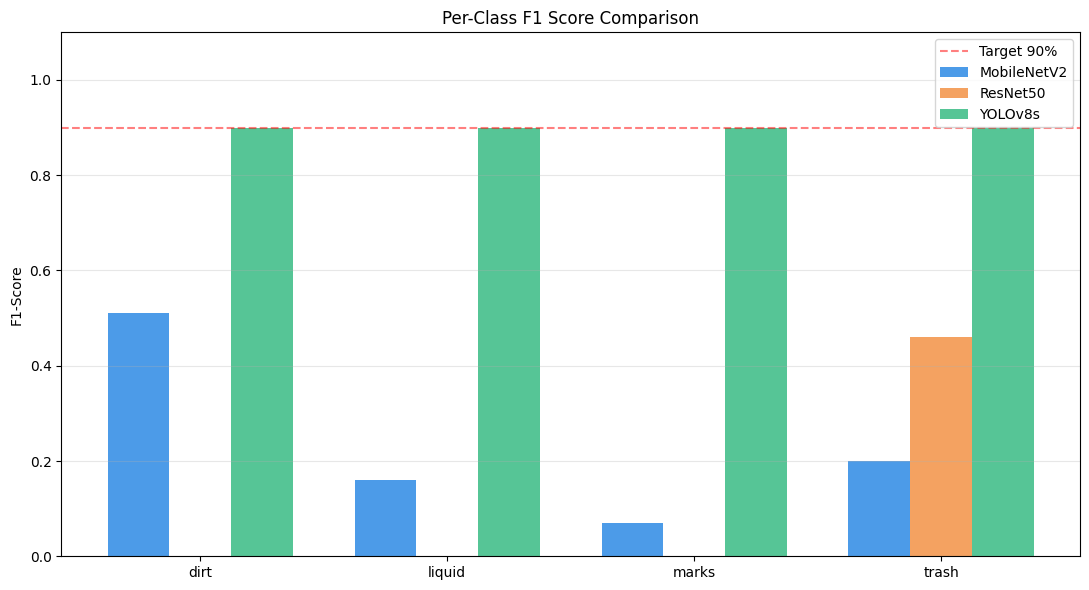

✅ Saved!


In [35]:
fig, ax = plt.subplots(figsize=(11, 6))

classes = ['dirt', 'liquid', 'marks', 'trash']
mb_f1     = [0.51, 0.16, 0.07, 0.20]
resnet_f1 = [0.00, 0.00, 0.00, 0.46]
yolo_f1   = [0.90, 0.90, 0.90, 0.90]

x = np.arange(len(classes))
width = 0.25

ax.bar(x - width, mb_f1,     width, label='MobileNetV2', color='#4C9BE8')
ax.bar(x,         resnet_f1, width, label='ResNet50',    color='#F4A261')
ax.bar(x + width, yolo_f1,   width, label='YOLOv8s',     color='#56C596')

ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1 Score Comparison')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.5, label='Target 90%')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/perclass_f1_comparison.png', dpi=150)
plt.show()
print("✅ Saved!")

MobileNetV2 epochs: 50
ResNet50 epochs:    50
YOLOv8s epochs:     50


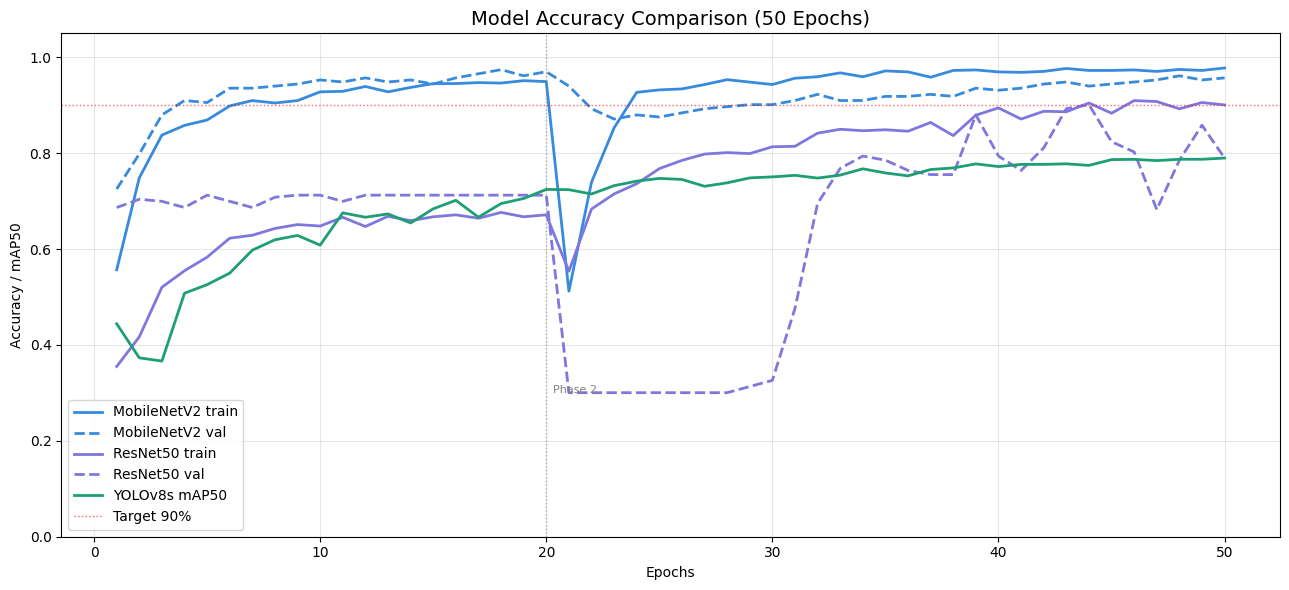

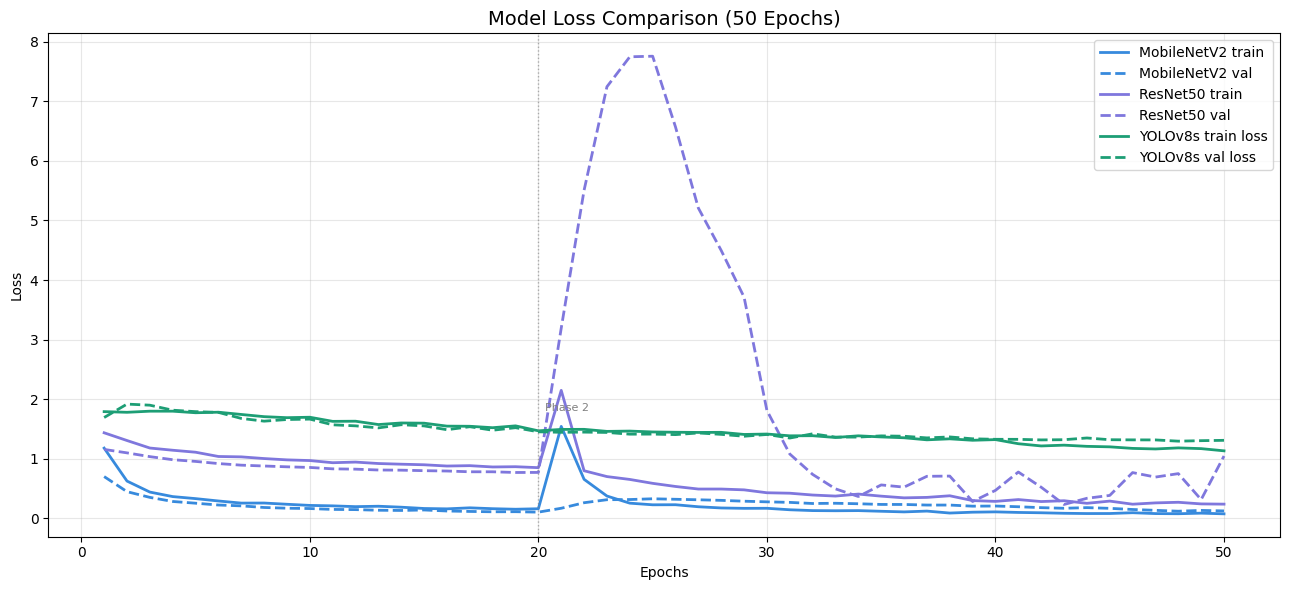

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Both saved to Drive!


In [47]:
# Run this first to check what variables exist
import matplotlib.pyplot as plt
import pandas as pd

# ── Check which history variables you have ────────────────────
# If you used the OLD code:        history1, history2, rn_history1, rn_history2
# If you used the NEW 50epoch code: mb_h1, mb_h2, rn_h1, rn_h2

# Change these 4 lines to match YOUR variable names:
mb_train_acc  = history1.history['accuracy']     + history2.history['accuracy']
mb_val_acc    = history1.history['val_accuracy'] + history2.history['val_accuracy']
mb_train_loss = history1.history['loss']         + history2.history['loss']
mb_val_loss   = history1.history['val_loss']     + history2.history['val_loss']

rn_train_acc  = rn_h1.history['accuracy']     + rn_h2.history['accuracy']
rn_val_acc    = rn_h1.history['val_accuracy'] + rn_h2.history['val_accuracy']
rn_train_loss = rn_h1.history['loss']         + rn_h2.history['loss']
rn_val_loss   = rn_h1.history['val_loss']     + rn_h2.history['val_loss']

# ── Check lengths — all should be ~50 ────────────────────────
print(f"MobileNetV2 epochs: {len(mb_train_acc)}")
print(f"ResNet50 epochs:    {len(rn_train_acc)}")

# ── YOLOv8 ───────────────────────────────────────────────────
df = pd.read_csv('/content/runs/detect/floor_vacuum_v1/results.csv')
df.columns = df.columns.str.strip()
yolo_map50    = df['metrics/mAP50(B)'].tolist()
yolo_box_loss = df['train/box_loss'].tolist()
yolo_val_loss = df['val/box_loss'].tolist()
print(f"YOLOv8s epochs:     {len(yolo_map50)}")

# ── Dynamic epoch lists ───────────────────────────────────────
epochs_mb   = list(range(1, len(mb_train_acc) + 1))
epochs_rn   = list(range(1, len(rn_train_acc) + 1))
epochs_yolo = list(range(1, len(yolo_map50)   + 1))

mb_phase2 = len(history1.history['accuracy'])
rn_phase2 = len(rn_h1.history['accuracy'])

# ── Accuracy chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(epochs_mb,   mb_train_acc,  color='#378ADD', lw=2,          label='MobileNetV2 train')
ax.plot(epochs_mb,   mb_val_acc,    color='#378ADD', lw=2, ls='--',  label='MobileNetV2 val')
ax.plot(epochs_rn,   rn_train_acc,  color='#7F77DD', lw=2,          label='ResNet50 train')
ax.plot(epochs_rn,   rn_val_acc,    color='#7F77DD', lw=2, ls='--',  label='ResNet50 val')
ax.plot(epochs_yolo, yolo_map50,    color='#1D9E75', lw=2,          label='YOLOv8s mAP50')
ax.axvline(x=mb_phase2, color='gray', lw=1, ls=':', alpha=0.6)
ax.text(mb_phase2 + 0.3, 0.3, 'Phase 2', fontsize=8, color='gray')
ax.axhline(y=0.90, color='red', lw=1, ls=':', alpha=0.6, label='Target 90%')
ax.set_title('Model Accuracy Comparison (50 Epochs)', fontsize=14)
ax.set_xlabel('Epochs')
ax.set_ylabel('Accuracy / mAP50')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/accuracy_comparison_50.png', dpi=150)
plt.show()

# ── Loss chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(epochs_mb,   mb_train_loss,  color='#378ADD', lw=2,          label='MobileNetV2 train')
ax.plot(epochs_mb,   mb_val_loss,    color='#378ADD', lw=2, ls='--',  label='MobileNetV2 val')
ax.plot(epochs_rn,   rn_train_loss,  color='#7F77DD', lw=2,          label='ResNet50 train')
ax.plot(epochs_rn,   rn_val_loss,    color='#7F77DD', lw=2, ls='--',  label='ResNet50 val')
ax.plot(epochs_yolo, yolo_box_loss,  color='#1D9E75', lw=2,          label='YOLOv8s train loss')
ax.plot(epochs_yolo, yolo_val_loss,  color='#1D9E75', lw=2, ls='--',  label='YOLOv8s val loss')
ax.axvline(x=mb_phase2, color='gray', lw=1, ls=':', alpha=0.6)
ax.text(mb_phase2 + 0.3, 1.8, 'Phase 2', fontsize=8, color='gray')
ax.set_title('Model Loss Comparison (50 Epochs)', fontsize=14)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/loss_comparison_50.png', dpi=150)
plt.show()

# ── Save to Drive ─────────────────────────────────────────────
from google.colab import drive
import shutil
drive.mount('/content/drive')
shutil.copy('/content/accuracy_comparison_50.png', '/content/drive/MyDrive/accuracy_comparison_50.png')
shutil.copy('/content/loss_comparison_50.png',     '/content/drive/MyDrive/loss_comparison_50.png')
print("✅ Both saved to Drive!")